# Assignment 3 — Predicting Manufacturing Quality Tiers with an Artificial Neural Network

**Author:** Bibash Gautam  
**Course:** Machine Learning — Master of Data Analytics  
**Dataset:** `Manufacturing_Quality_Tiers_v2.xlsx`  
**Target:** `quality_tier` — Poor / Acceptable / Good / Excellent (4-class, ordinal)

---

### How this notebook is organised

| Section | Content |
|---|---|
| Part A | Pre-analysis and hypotheses |
| Part B | Experimental design — split, encoding, scaling, metric justification |
| Part C | ANN construction and architectural rationale |
| Part D | Hyperparameter exploration |
| Part E | Regularization and generalization — learning curves |
| Part F | Final test evaluation and error analysis |
| Part G | ANN vs. classical baselines, deployment recommendation |

**Tooling note.** The MLP is built with `scikit-learn`'s `MLPClassifier`, driven **one epoch at a time**
via `partial_fit`. This is deliberate: it gives me the same per-epoch control over training and
validation curves that Keras would, without the framework dependency, and every architectural
choice (depth, width, activation, optimizer, loss, regularization) stays explicit in the code.
No AutoML and no black-box search routine is used anywhere — every configuration is chosen and
justified by hand.

In [1]:
# Environment setup 

import warnings, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix, log_loss,
                             ConfusionMatrixDisplay, balanced_accuracy_score)
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
np.random.seed(SEED)


TIER_ORDER = ["Poor", "Acceptable", "Good", "Excellent"]

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 160
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)

print("Environment ready. Seed =", SEED)

Environment ready. Seed = 42


---
# Part A — Pre-Analysis and Hypotheses

These four answers were written **before** I looked at any model output. I am recording them here
so that Part F and Part G can honestly check them rather than rationalise whatever happened to come out.

### A1. Do I expect the ANN to outperform the classical models?

**Yes, but by a modest and possibly unimpressive margin — and only against Logistic Regression.**

My reasoning comes from what the data dictionary actually says about this dataset. It explicitly
describes *nonlinear feature interactions*, and that is exactly the condition under which a
multilayer perceptron has a structural advantage: hidden layers with nonlinear activations can
compose features into interaction terms automatically, whereas Logistic Regression can only draw a
set of linear boundaries in the original feature space (Goodfellow et al., 2016). If quality
genuinely depends on something like *vibration × machine age* or *temperature deviation squared*,
Logistic Regression cannot represent that unless I hand-engineer the term, and I am deliberately
not doing so.

Against a **Decision Tree** I am much less confident. Trees also capture nonlinearity and
interactions, they do it through axis-aligned splits, and on tabular data of this size they are
frequently competitive with or better than neural networks (Grinsztajn et al., 2022). So my honest
hypothesis is: ANN > Logistic Regression fairly clearly, ANN ≈ Decision Tree, with the winner
decided by how smooth the true decision boundary is. If the boundaries are smooth and diagonal, the
ANN wins; if they are threshold-like ("defects above 8 is always Poor"), the tree wins.

I also expect the *practical* margin to be small. This is a modest tabular dataset, not the
high-dimensional perceptual data where deep networks dominate.

### A2. Which features do I expect to interact non-linearly?

- **`vibration_level` × `machine_age`** — a given vibration reading is not equally worrying on a new
  machine and on a twenty-year-old one. Vibration on old equipment likely signals bearing wear;
  the same reading on a new machine may be normal. This is a textbook multiplicative interaction.
- **`operating_temperature`** on its own — I expect a **non-monotonic** effect. Processes usually
  have an optimal thermal window, so both too cold and too hot should degrade quality. A linear
  model must pick one direction and will therefore fit this badly.
- **`production_speed` × `workload_index`** — running fast is probably fine under light load and
  damaging under heavy load. Speed alone should be a weak predictor; speed conditioned on workload
  should be strong.
- **`maintenance_frequency` × `machine_age` × `defect_history`** — maintenance should matter far
  more for old, historically defective machines. A three-way interaction like this is precisely
  what a hidden layer can approximate and a linear model cannot.
- **`operator_experience`** — I expect **diminishing returns**: the jump from 1 to 5 years should
  matter much more than 20 to 25. That is a concave, saturating relationship.
- **`shift_type` × `downtime_hours`** — night shifts typically have thinner supervision and slower
  maintenance response, so the same downtime may carry a different quality penalty by shift.

### A3. What challenges might the ANN face here?

1. **Sample size relative to parameter count.** A network with two hidden layers of 64 and 32 units
   on ~20 encoded inputs already carries a few thousand weights. On a tabular dataset of this scale
   the model can memorise the training set long before it generalises, so overfitting is the primary
   risk, not underfitting.
2. **Mixed feature types.** Neural networks need everything numeric and on a comparable scale.
   `defect_history` (counts), `operating_temperature` (tens), and `workload_index` (around 1) live
   on wildly different scales; without standardisation the loss surface becomes badly conditioned
   and gradient descent crawls along the dominant directions (LeCun et al., 2012).
3. **The target is ordinal but the loss is not.** Cross-entropy treats "predicted Poor, actually
   Excellent" as exactly as wrong as "predicted Poor, actually Acceptable." Manufacturing does not
   see it that way. The model has no built-in reason to keep its errors adjacent.
4. **Class imbalance.** If Poor and Excellent are the tails of an underlying continuous quality
   score, they will be rarer, and the network will be tempted to bank accuracy on the middle classes.
5. **Sensitivity to initialisation and learning rate.** Unlike Logistic Regression, the MLP loss is
   non-convex, so results move with the seed and a badly chosen learning rate can stall training or
   oscillate.
6. **Interpretability.** Even if the ANN wins, a plant engineer cannot read a weight matrix the way
   they can read a tree, which matters for a deployment argument.

### A4. Which tier will be hardest to classify?

I expect the **middle tiers — `Acceptable` and `Good` — to be the hardest, with `Acceptable` the worst.**

The reasoning is about geometry, not frequency. If the four tiers are cut from an underlying
continuous quality score, then `Poor` and `Excellent` occupy the extremes and each has only **one**
neighbouring class to be confused with. `Acceptable` and `Good` sit in the middle with a boundary on
**both** sides, so they have twice the boundary surface on which to lose examples, and the records
sitting just either side of a cut point are close to indistinguishable on the measured features.

`Acceptable` should edge out `Good` as hardest because it is squeezed between `Poor` below and
`Good` above while likely being less frequent than `Good`.

**Concrete falsifiable prediction:** per-class recall will follow roughly
`Excellent ≈ Poor > Good > Acceptable`, and the largest off-diagonal counts in the confusion matrix
will be **adjacent-tier** confusions (Acceptable↔Good above all), not two-tier jumps like Poor↔Good.
Part F tests this directly.

---
# Part B — Experimental Design

## B.1 Load the data and inspect it

In [2]:
# Load the dataset.
# The file is searched for in a few common locations so the notebook runs
# unchanged whether the .xlsx sits beside it or in a data/ subfolder.

from pathlib import Path

CANDIDATES = [
    "Manufacturing_Quality_Tiers_v2.xlsx",
    "ML_Assignment3_Manufacturing_Quality_Tiers.xlsx",
    "data/Manufacturing_Quality_Tiers_v2.xlsx",
]
path = next((Path(p) for p in CANDIDATES if Path(p).exists()), None)
if path is None:                      # fall back to any .xlsx in the folder
    found = sorted(Path(".").glob("*.xlsx"))
    if not found:
        raise FileNotFoundError(
            "Could not find the dataset. Put Manufacturing_Quality_Tiers_v2.xlsx "
            "in the same folder as this notebook."
        )
    path = found[0]

df = pd.read_excel(path)
print(f"Loaded : {path.name}")
print(f"Shape  : {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Loaded : ML_Assignment3_Manufacturing_Quality_Tiers.xlsx
Shape  : 1000 rows x 16 columns


,machine_id,machine_age,operating_temperature,vibration_level,production_speed,maintenance_frequency,operator_experience,defect_history,shift_type,downtime_hours,material_quality_score,inspection_score,workload_index,factory_section,installation_month,quality_tier
0,1,16,113,2.20,105,2,6,4,Day,7.80,66,58,4,A,12,Acceptable
1,2,17,98,3.78,81,10,17,30,Day,19.59,99,74,4,B,8,Acceptable
2,3,3,112,0.66,408,2,2,2,Day,14.13,97,58,9,D,3,Acceptable
3,4,10,115,3.97,342,4,1,19,Evening,13.65,43,69,1,C,5,Poor
4,5,10,48,6.24,448,3,22,14,Day,13.96,42,41,8,D,1,Acceptable


In [3]:
# ---- Structural overview: dtypes, missingness, cardinality 
overview = pd.DataFrame({
    "dtype":     df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
    "n_unique":  df.nunique(),
    "example":   [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
})
display(overview)

print("Duplicate rows (ignoring machine_id):",
      df.drop(columns=["machine_id"], errors="ignore").duplicated().sum())

,dtype,n_missing,pct_missing,n_unique,example
machine_id,int64,0,0.0,1000,1
machine_age,int64,0,0.0,20,16
operating_temperature,int64,0,0.0,81,113
vibration_level,float64,0,0.0,556,2.2
production_speed,int64,0,0.0,403,105
maintenance_frequency,int64,0,0.0,12,2
operator_experience,int64,0,0.0,25,6
defect_history,int64,0,0.0,31,4
shift_type,str,0,0.0,3,Day
downtime_hours,float64,0,0.0,776,7.8


Duplicate rows (ignoring machine_id): 0


In [4]:
# ---- Descriptive statistics for the numeric features ----------------------

num_desc = df.select_dtypes(include=np.number).drop(columns=["machine_id"], errors="ignore").describe().T
num_desc["range"] = num_desc["max"] - num_desc["min"]
display(num_desc.round(2))

,count,mean,std,min,25%,50%,75%,max,range
machine_age,1000.0,10.51,5.88,1.00,5.75,10.00,16.00,20.00,19.00
operating_temperature,1000.0,78.28,23.43,40.00,57.00,77.00,99.00,120.00,80.00
vibration_level,1000.0,4.31,2.19,0.50,2.37,4.33,6.25,7.99,7.49
production_speed,1000.0,271.88,135.16,50.00,154.00,274.00,394.25,500.00,450.00
maintenance_frequency,1000.0,6.47,3.50,1.00,4.00,6.50,10.00,12.00,11.00
operator_experience,1000.0,12.76,7.28,1.00,7.00,12.00,19.00,25.00,24.00
defect_history,1000.0,15.17,9.07,0.00,7.00,15.50,23.00,30.00,30.00
downtime_hours,1000.0,9.67,5.74,0.02,4.62,9.78,14.42,19.98,19.96
material_quality_score,1000.0,71.14,18.05,40.00,56.00,71.00,87.00,100.00,60.00
inspection_score,1000.0,69.99,17.76,40.00,55.00,70.00,86.00,100.00,60.00


,count,percent
quality_tier,,
Poor,191,19.1
Acceptable,604,60.4
Good,204,20.4
Excellent,1,0.1


Imbalance ratio (largest / smallest class): 604.00
Majority-class baseline accuracy          : 0.6040
  -> any model must beat this number to be doing anything at all.


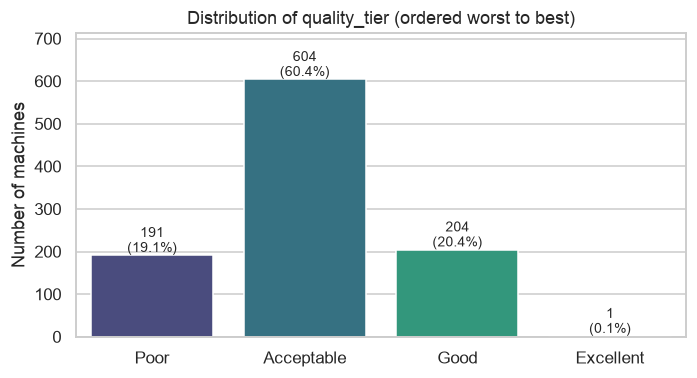

In [5]:
# ---- Target distribution 
tier_counts = df["quality_tier"].value_counts().reindex(TIER_ORDER)
tier_pct    = (tier_counts / len(df) * 100).round(1)
summary = pd.DataFrame({"count": tier_counts, "percent": tier_pct})
display(summary)

imbalance_ratio = tier_counts.max() / tier_counts.min()
print(f"Imbalance ratio (largest / smallest class): {imbalance_ratio:.2f}")
print(f"Majority-class baseline accuracy          : {tier_counts.max()/len(df):.4f}")
print("  -> any model must beat this number to be doing anything at all.")

fig, ax = plt.subplots(figsize=(6.5, 3.6))
sns.barplot(x=tier_counts.index, y=tier_counts.values, ax=ax,
            palette="viridis", hue=tier_counts.index, legend=False)
for i, v in enumerate(tier_counts.values):
    ax.text(i, v + len(df)*0.008, f"{v}\n({tier_pct.iloc[i]}%)", ha="center", fontsize=9)
ax.set_title("Distribution of quality_tier (ordered worst to best)")
ax.set_ylabel("Number of machines"); ax.set_xlabel("")
ax.set_ylim(0, tier_counts.max()*1.18)
plt.tight_layout(); plt.show()

### Reading the target distribution

Two things from the table above drive later decisions. First, the **majority-class baseline** is the
floor any model has to clear — quoting an accuracy below that number would mean the model is worse
than a constant prediction. Second, the **imbalance ratio** tells me whether plain accuracy is a
trustworthy headline metric. The more uneven the classes, the more accuracy rewards a model for
simply favouring the big classes, which is precisely the failure mode I care about avoiding here
(see B.5).

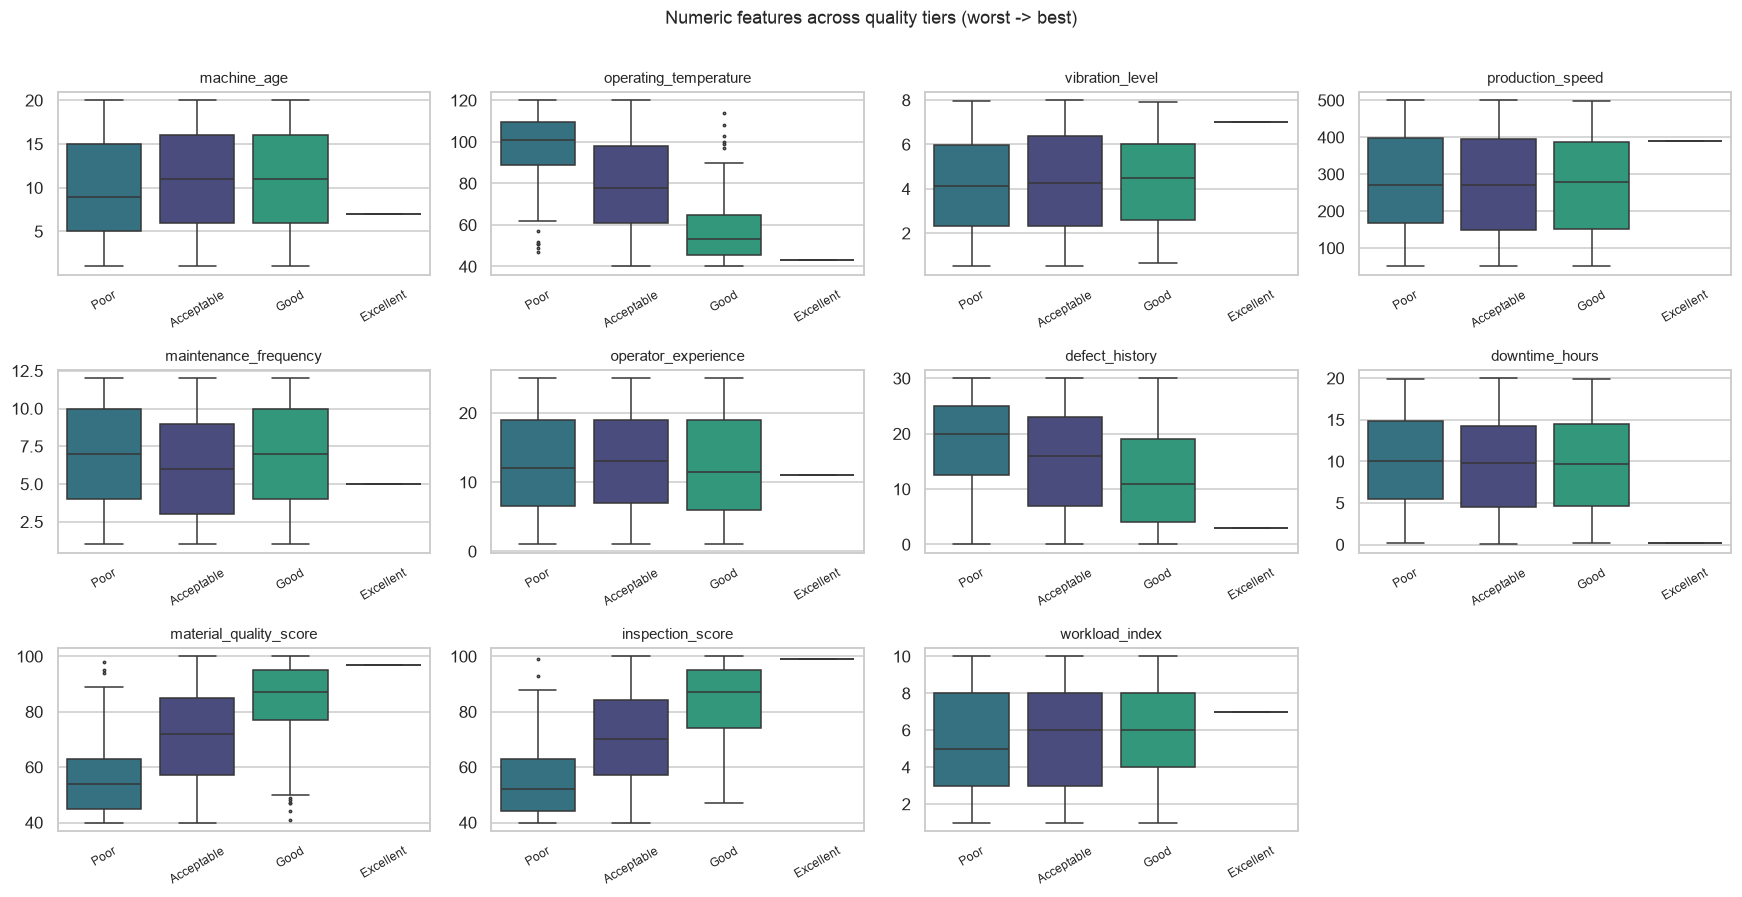

In [6]:
# ---- Feature distributions by tier: is there visible non-linearity? -------
# This plot is the empirical check on hypothesis A2. A feature whose class
# medians move monotonically is linearly separable; one whose classes overlap
# heavily or peak in the middle needs a nonlinear model.
numeric_feats = [c for c in df.select_dtypes(include=np.number).columns
                 if c not in ("machine_id", "installation_month")]

n = len(numeric_feats)
ncol = 4; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.0*ncol, 2.7*nrow))
for ax, col in zip(axes.ravel(), numeric_feats):
    sns.boxplot(data=df, x="quality_tier", y=col, order=TIER_ORDER, ax=ax,
                palette="viridis", hue="quality_tier", legend=False, fliersize=1.5)
    ax.set_title(col, fontsize=10); ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(axis="x", labelrotation=30, labelsize=8)
for ax in axes.ravel()[n:]:
    ax.axis("off")
fig.suptitle("Numeric features across quality tiers (worst -> best)", y=1.005, fontsize=12)
plt.tight_layout(); plt.show()

In [7]:
# ---- Linear-signal audit ---------------------------------------------------
# Spearman correlation between each numeric feature and the ORDINAL rank of the
# tier. A feature with |rho| near zero is not useless -- it may still matter
# through an interaction, which is exactly the gap an ANN is supposed to close.
tier_rank = df["quality_tier"].map({t: i for i, t in enumerate(TIER_ORDER)})

rho = (df[numeric_feats]
       .apply(lambda s: s.corr(tier_rank, method="spearman"))
       .sort_values(key=np.abs, ascending=False)
       .rename("spearman_rho_with_tier_rank")
       .to_frame().round(3))
display(rho)

print(textwrap.fill(
    "Features near the bottom of this table carry little MONOTONIC signal. If the ANN "
    "still outperforms Logistic Regression, the extra performance must be coming from "
    "interactions or curvature that this table cannot show -- which is the core claim in A1.", 100))

,spearman_rho_with_tier_rank
operating_temperature,-0.552
inspection_score,0.493
material_quality_score,0.486
defect_history,-0.211
machine_age,0.066
vibration_level,0.033
workload_index,0.033
maintenance_frequency,0.024
operator_experience,-0.022
production_speed,-0.010


Features near the bottom of this table carry little MONOTONIC signal. If the ANN still outperforms
Logistic Regression, the extra performance must be coming from interactions or curvature that this
table cannot show -- which is the core claim in A1.


Categorical features: ['shift_type', 'factory_section']


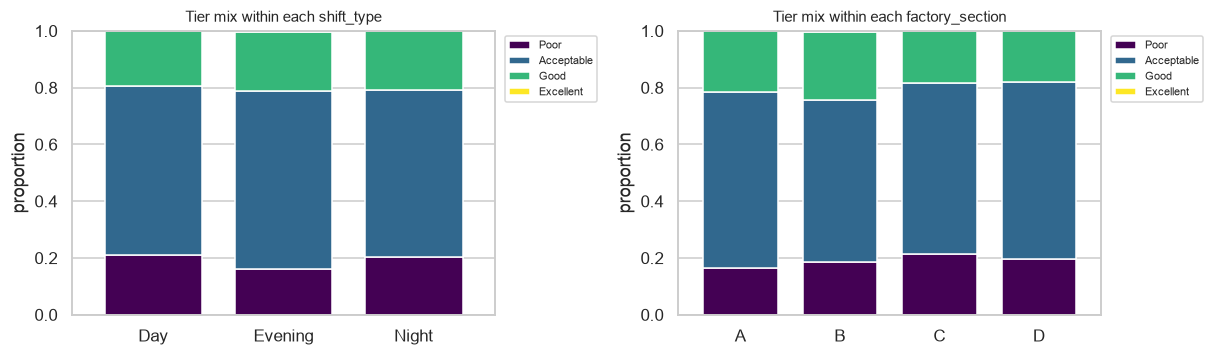

        shift_type: max shift in any tier's share across levels = 0.051
   factory_section: max shift in any tier's share across levels = 0.059


In [8]:
# ---- Categorical features vs tier -----------------------------------------
# NOTE: `dtype == object` is not reliable across pandas versions (pandas 3.x
# gives string columns their own dtype), so test numeric-ness directly.
is_cat = lambda s: not pd.api.types.is_numeric_dtype(s)
cat_feats = [c for c in df.columns if is_cat(df[c]) and c not in ("machine_id", "quality_tier")]
print("Categorical features:", cat_feats)

if cat_feats:
    fig, axes = plt.subplots(1, len(cat_feats), figsize=(5.6*len(cat_feats), 3.4), squeeze=False)
    for ax, col in zip(axes[0], cat_feats):
        ct = pd.crosstab(df[col], df["quality_tier"], normalize="index")[TIER_ORDER]
        ct.plot(kind="bar", stacked=True, ax=ax, colormap="viridis", width=.75)
        ax.set_title(f"Tier mix within each {col}", fontsize=10)
        ax.set_ylabel("proportion"); ax.set_xlabel("")
        ax.tick_params(axis="x", labelrotation=0)
        ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout(); plt.show()

    # A flat stacked bar means the category carries no marginal signal.
    for col in cat_feats:
        ct = pd.crosstab(df[col], df["quality_tier"], normalize="index")[TIER_ORDER]
        spread = (ct.max() - ct.min()).max()
        print(f"{col:>18}: max shift in any tier's share across levels = {spread:.3f}")

## B.2 Train / validation / test split

I use a **three-way 60 / 20 / 20 stratified split** rather than the more common two-way split:

- **Train (60%)** — weight updates only.
- **Validation (20%)** — every architecture and hyperparameter decision in Parts C, D and E is made
  on this set, and every learning curve is plotted against it.
- **Test (20%)** — locked away and not touched until Part F.

The reason for carving out a separate validation set is methodological. In Part D I compare six
configurations and then pick the best one. If I selected on the test set, the reported test score
would be optimistically biased — I would effectively be fitting the test set through my own
selection choices. Keeping selection and final reporting on different data is what makes the Part F
number an honest estimate of generalization.

**Stratification** preserves the tier proportions in all three splits. Without it, a rare tier could
end up under-represented in validation, making the validation curve noisy and the model-selection
decision unreliable. **The seed is fixed at 42** throughout so every number in this notebook is
reproducible.

In [ ]:

# Feature / target separation and the three-way stratified split

TARGET = "quality_tier"
DROP   = ["machine_id"]

X = df.drop(columns=[TARGET] + [c for c in DROP if c in df.columns])
y_raw = df[TARGET]

# Encode the target in ORDINAL order (Poor=0 ... Excellent=3), not alphabetically.
le = LabelEncoder().fit(TIER_ORDER)
y = le.transform(y_raw)
CLASS_NAMES = list(le.classes_)
print("Class encoding:", dict(zip(CLASS_NAMES, range(len(CLASS_NAMES)))))


X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)
# Split 2: carve validation (20% of total = 25% of the remaining 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp)

print(f"\nTrain : {X_train.shape[0]:>5} rows ({X_train.shape[0]/len(X):.0%})")
print(f"Val   : {X_val.shape[0]:>5} rows ({X_val.shape[0]/len(X):.0%})")
print(f"Test  : {X_test.shape[0]:>5} rows ({X_test.shape[0]/len(X):.0%})")

# Confirm stratification actually worked
prop = pd.DataFrame({
    "train": pd.Series(y_train).value_counts(normalize=True).sort_index().values,
    "val":   pd.Series(y_val).value_counts(normalize=True).sort_index().values,
    "test":  pd.Series(y_test).value_counts(normalize=True).sort_index().values,
}, index=CLASS_NAMES).round(3)
print("\nClass proportions per split (should be near-identical):")
display(prop)

ValueError: y contains previously unseen labels: np.str_('Excellent')

## B.3 Encoding decisions

| Feature | Treatment | Why |
|---|---|---|
| `machine_id` | **dropped** | Non-informative identifier. Keeping it invites memorisation. |
| `shift_type` | **one-hot** (3 columns) | Nominal with no natural order. Integer-coding Day=0/Evening=1/Night=2 would falsely tell the network that Night is "twice" Evening. |
| `factory_section` | **one-hot** | Same argument — sections are labels, not quantities. |
| `installation_month` | **cyclical sine/cosine** | This is the one non-obvious choice. Month is stored 1–12, but December (12) and January (1) are *adjacent* in time, yet numerically 11 apart. Encoding it as `sin(2πm/12)` and `cos(2πm/12)` places the months on a circle so that December and January end up neighbours, which is what any seasonal effect actually looks like. One-hot would also work but costs 12 columns and throws away the ordering entirely. |
| all other numerics | **kept as-is, then scaled** | Genuinely continuous quantities. |

I do **not** drop a level when one-hot encoding. Dropping a reference category is needed to avoid
perfect collinearity in an unregularised linear model, but the MLP is L2-regularised via `alpha`
and is not fit by matrix inversion, so collinearity is harmless here. Keeping all levels also means
each category gets its own weight, which is slightly easier to reason about.

## B.4 Scaling decision

**`StandardScaler` on every numeric feature (zero mean, unit variance), fitted on the training split only.**

This is not optional for a neural network. The descriptive table in B.1 shows features whose
standard deviations differ by an order of magnitude. Since the first-layer gradient for a weight is
proportional to its input, large-scale features produce large gradients and small-scale features
produce tiny ones. With a single shared learning rate, the optimiser is forced to take steps that
are simultaneously too big for one direction and too small for another — it oscillates along the
steep axis while barely moving along the flat one. Standardising makes the loss surface far better
conditioned and lets one learning rate serve all weights (LeCun et al., 2012). Scaling also keeps
pre-activations in the region where ReLU is informative rather than saturating whole units at zero.

The scaler is fit on **train only** and then applied to validation and test. Fitting on the full
dataset would leak the test distribution's mean and variance into training — a subtle but real form
of data leakage that inflates the final score.

Everything is wrapped in a `ColumnTransformer` so the fit/transform boundary is enforced by the
code rather than by my own discipline.

In [ ]:
# Preprocessing: cyclical month encoding + one-hot + standardisation

from sklearn.preprocessing import FunctionTransformer

def cyclical_month(Xm):
    """Map month 1-12 onto the unit circle so Dec and Jan are neighbours."""
    m = np.asarray(Xm, dtype=float).reshape(-1, 1)
    return np.hstack([np.sin(2*np.pi*m/12.0), np.cos(2*np.pi*m/12.0)])

def cyclical_month_names(transformer, input_features):
    """One input column becomes TWO output columns, so name them explicitly.
    (feature_names_out="one-to-one" would be wrong here and breaks
     preprocessor.get_feature_names_out() later in Part G.)"""
    return np.array([f"{f}_sin" for f in input_features]
                    + [f"{f}_cos" for f in input_features], dtype=object)

cat_cols   = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]
month_cols = [c for c in X.columns if c == "installation_month"]
num_cols   = [c for c in X.columns if c not in cat_cols + month_cols]

print("Categorical  ->", cat_cols)
print("Cyclical     ->", month_cols)
print("Numeric      ->", num_cols)

transformers = [("num", StandardScaler(), num_cols)]
if month_cols:
    transformers.append(("month", Pipeline([
        ("cyc", FunctionTransformer(cyclical_month, feature_names_out=cyclical_month_names)),
        ("sc",  StandardScaler()),
    ]), month_cols))
if cat_cols:
    transformers.append(("cat", OneHotEncoder(handle_unknown="ignore",
                                              sparse_output=False), cat_cols))

preprocessor = ColumnTransformer(transformers, remainder="drop")

# FIT ON TRAIN ONLY -- then transform val and test with those same statistics.
Xtr = preprocessor.fit_transform(X_train)
Xva = preprocessor.transform(X_val)
Xte = preprocessor.transform(X_test)

print(f"\nEncoded feature matrix: {Xtr.shape[1]} columns "
      f"(from {X.shape[1]} raw features)")
print(f"Train {Xtr.shape} | Val {Xva.shape} | Test {Xte.shape}")

# Sanity check that scaling did what it should
print(f"\nTrain numeric block  mean ~ {Xtr[:, :len(num_cols)].mean():+.6f} "
      f"(target 0), std ~ {Xtr[:, :len(num_cols)].std():.4f} (target 1)")
print(f"Val   numeric block  mean ~ {Xva[:, :len(num_cols)].mean():+.4f} "
      f"(near 0, but NOT exactly -- correct, it was not fit on val)")

## B.5 Evaluation metric justification

**Primary metric: macro-averaged F1.** **Secondary: balanced accuracy, per-class recall, and the
confusion matrix.** Plain accuracy is reported but is *not* the metric I select on.

The reasoning is specific to this problem, not generic:

1. **Accuracy is dominated by the majority tiers.** With uneven classes, a model can post a
   respectable accuracy while barely recognising the rarest tier. Macro-F1 averages the per-class
   F1 scores with **equal weight per class**, so ignoring a small class visibly costs the score.

2. **The rare tiers are the operationally important ones.** `Poor` output is what triggers a line
   stoppage or a rework order, and `Excellent` is what a premium customer specification depends on.
   A metric that quietly discounts them is measuring the wrong thing for the business.

3. **Precision and recall are not interchangeable here, so F1 is the right compromise.** Missing a
   `Poor` machine (low recall) means defective product ships. Wrongly flagging a good machine as
   `Poor` (low precision) means unnecessary downtime. Both are real costs, so I want a metric that
   punishes either failure — which is exactly the harmonic mean.

4. **The confusion matrix is reported alongside, not as decoration.** Because the target is
   *ordinal*, a Poor→Acceptable error and a Poor→Excellent error carry very different consequences
   but identical weight in F1. No single scalar captures that, so Part F reads the matrix directly
   and separates adjacent-tier errors from severe multi-tier errors.

5. **Cross-entropy (log-loss) is the training loss, but not the reporting metric.** It is the right
   quantity to *optimise* — it is differentiable and pairs correctly with a softmax output — but it
   is not interpretable to a plant manager, so it appears in learning curves rather than in the
   headline results.

---
# Part C — ANN Construction

## C.1 The architecture and why each piece is what it is

| Component | Choice | Justification |
|---|---|---|
| **Input layer** | one unit per encoded column | Fixed by the preprocessing in B.4. |
| **Hidden layers** | **2 layers** | One hidden layer is a universal approximator in principle, but a second layer lets the network compose *interactions of interactions* with far fewer units than a single wide layer would need. Two layers is the standard starting point for tabular data; three or more is where overfitting risk climbs sharply on a dataset this size (A3, point 1). |
| **Neurons** | **64 → 32** (funnel) | The first layer is wide enough to form a rich set of interaction detectors from ~20 inputs; the second compresses them toward the 4-way decision. A narrowing funnel forces the network to summarise rather than pass features through unchanged. |
| **Activation** | **ReLU** | Non-saturating for positive inputs, so gradients do not vanish through the second layer the way they do with sigmoid or tanh, and it is cheap to compute. The nonlinearity is the entire point — without it, stacked layers collapse to a single linear map and the ANN would be no better than Logistic Regression. |
| **Output layer** | 4 units, **softmax** | One unit per tier; softmax converts the logits into a proper probability distribution over mutually exclusive classes. `MLPClassifier` applies this automatically for multiclass targets. |
| **Loss** | **categorical cross-entropy** (`log_loss`) | The correct loss for a softmax output. It penalises confident wrong predictions steeply and, paired with softmax, gives a clean gradient that avoids the learning slowdown you get from squared error on a saturating output. |
| **Optimizer** | **Adam**, `learning_rate_init = 1e-3` | Adam adapts a per-parameter step size from running estimates of the gradient's first and second moments, which makes it far more forgiving than plain SGD on features that still differ somewhat in effective scale (Kingma & Ba, 2015). It is also robust enough that I can vary architecture in Part D without re-tuning the learning rate for every single configuration. |
| **Batch size** | **32** | Small enough that the gradient noise acts as a mild regulariser and the model gets many updates per epoch; large enough to stay computationally sensible. |
| **L2 penalty** | `alpha = 1e-4` | A light default. Part E deliberately varies this to show what regularization does. |
| **Epochs** | up to **200**, curve-monitored | I do not trust a fixed epoch count. Training runs epoch-by-epoch and the validation curve decides where the useful stopping point is. |

**Why this architecture suits *this* problem specifically.** The dictionary promises nonlinear
feature interactions, and hidden ReLU layers are the mechanism that builds them automatically —
that is the one thing Logistic Regression structurally cannot do (A1). At the same time, the
dataset is modest, so the design is deliberately restrained: two layers, a funnel, and a real L2
penalty, rather than the wide deep stack that would memorise the training set within a few dozen
epochs.

## C.2 Epoch-level training harness

`MLPClassifier.partial_fit` performs exactly **one epoch** over the data. Calling it in a loop and
recording metrics after each call gives me true per-epoch training *and validation* curves — which
is what Part E needs. The built-in `loss_curve_` only tracks training loss, which would make
overfitting invisible.

In [ ]:
# ============================================================================
# Training harness: run an MLP one epoch at a time and record the full history.
# ============================================================================
def train_mlp_with_history(Xtr, ytr, Xva, yva, *, hidden_layer_sizes=(64, 32),
                           activation="relu", solver="adam", alpha=1e-4,
                           learning_rate_init=1e-3, batch_size=32,
                           max_epochs=200, seed=SEED, verbose_every=0):
    """
    Train an MLPClassifier epoch-by-epoch, capturing train/validation loss and
    accuracy after every epoch.

    Returns (fitted_model, history_dataframe).

    Using partial_fit rather than .fit(max_iter=N) is what makes the validation
    curve possible: sklearn only stores the TRAINING loss internally, and a
    training curve alone cannot distinguish "still learning" from "memorising".
    """
    classes = np.unique(ytr)
    clf = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        solver=solver,
        alpha=alpha,                      # L2 penalty on the weights
        learning_rate_init=learning_rate_init,
        batch_size=batch_size,
        random_state=seed,
        max_iter=1,                       # irrelevant for partial_fit, kept explicit
        shuffle=True,
    )

    hist = {"epoch": [], "train_loss": [], "val_loss": [],
            "train_acc": [], "val_acc": [], "train_f1": [], "val_f1": []}

    for ep in range(1, max_epochs + 1):
        clf.partial_fit(Xtr, ytr, classes=classes)   # exactly one epoch

        # Probabilities are needed for cross-entropy; labels for accuracy/F1.
        ptr, pva = clf.predict_proba(Xtr), clf.predict_proba(Xva)
        ytr_hat, yva_hat = ptr.argmax(1), pva.argmax(1)

        hist["epoch"].append(ep)
        hist["train_loss"].append(log_loss(ytr, ptr, labels=classes))
        hist["val_loss"].append(log_loss(yva, pva, labels=classes))
        hist["train_acc"].append(accuracy_score(ytr, ytr_hat))
        hist["val_acc"].append(accuracy_score(yva, yva_hat))
        hist["train_f1"].append(f1_score(ytr, ytr_hat, average="macro", zero_division=0))
        hist["val_f1"].append(f1_score(yva, yva_hat, average="macro", zero_division=0))

        if verbose_every and ep % verbose_every == 0:
            print(f"  epoch {ep:>3} | train loss {hist['train_loss'][-1]:.4f} "
                  f"val loss {hist['val_loss'][-1]:.4f} | val macro-F1 {hist['val_f1'][-1]:.4f}")

    return clf, pd.DataFrame(hist)


def n_parameters(hidden_layer_sizes, n_in, n_out=4):
    """Total trainable weights + biases -- used to reason about capacity."""
    sizes = [n_in, *hidden_layer_sizes, n_out]
    return sum(sizes[i]*sizes[i+1] + sizes[i+1] for i in range(len(sizes)-1))

print("Training harness defined.")
print(f"Baseline (64, 32) has {n_parameters((64,32), Xtr.shape[1]):,} trainable parameters "
      f"for {Xtr.shape[0]:,} training rows "
      f"({n_parameters((64,32), Xtr.shape[1])/Xtr.shape[0]:.1f} parameters per row).")

> **Read that last number carefully.** The parameters-per-row ratio is the single best early
> warning of overfitting risk. When a model carries several trainable weights for every training
> example, it has more than enough freedom to memorise the training set outright. This is the
> quantitative version of hypothesis A3.1, and it is what Part E goes on to demonstrate.

In [ ]:
# ============================================================================
# Train the Part C baseline architecture
# ============================================================================
print("Training baseline ANN: (64, 32), ReLU, Adam, lr=1e-3, alpha=1e-4 ...")
ann_base, hist_base = train_mlp_with_history(
    Xtr, y_train, Xva, y_val,
    hidden_layer_sizes=(64, 32), alpha=1e-4,
    learning_rate_init=1e-3, max_epochs=200, verbose_every=40)

best_ep = int(hist_base["val_f1"].idxmax()) + 1
print(f"\nBest validation macro-F1 = {hist_base['val_f1'].max():.4f} at epoch {best_ep}")
print(f"Validation macro-F1 at final epoch 200 = {hist_base['val_f1'].iloc[-1]:.4f}")
print(f"Train / val accuracy at final epoch    = "
      f"{hist_base['train_acc'].iloc[-1]:.4f} / {hist_base['val_acc'].iloc[-1]:.4f}")

In [ ]:
# ---- Baseline learning curves ---------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_base.epoch, hist_base.train_loss, label="train", lw=1.8)
axes[0].plot(hist_base.epoch, hist_base.val_loss, label="validation", lw=1.8)
axes[0].axvline(hist_base.val_loss.idxmin()+1, ls="--", c="grey", lw=1,
                label=f"min val loss (ep {hist_base.val_loss.idxmin()+1})")
axes[0].set_title("Cross-entropy loss"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("log-loss")
axes[0].legend()

axes[1].plot(hist_base.epoch, hist_base.train_f1, label="train", lw=1.8)
axes[1].plot(hist_base.epoch, hist_base.val_f1, label="validation", lw=1.8)
axes[1].axvline(best_ep, ls="--", c="grey", lw=1, label=f"best val F1 (ep {best_ep})")
axes[1].set_title("Macro-F1"); axes[1].set_xlabel("epoch"); axes[1].set_ylabel("macro-F1")
axes[1].legend()

fig.suptitle("Part C baseline ANN (64, 32) — training vs validation", y=1.02)
plt.tight_layout(); plt.show()

gap = hist_base.train_acc.iloc[-1] - hist_base.val_acc.iloc[-1]
print(f"Generalization gap at epoch 200 (train acc - val acc): {gap:+.4f}")

---
# Part D — Hyperparameter Exploration

## D.1 What I am varying and why

The assignment requires at least two configurations. I test **six**, because two would not let me
separate the effect of *depth* from the effect of *width* from the effect of *step size* — and the
whole point of the exercise is to explain *why* performance moves, not just that it did.

Every configuration is written out by hand. There is no grid search object, no randomised search
and no AutoML anywhere: each row below is a deliberate one-factor-at-a-time change from the
baseline so the effect is attributable.

| # | Config | What changed vs. baseline | What I expect, and why |
|---|---|---|---|
| 1 | `(64, 32)`, lr 1e-3, α 1e-4 | — (Part C baseline) | Reference point. |
| 2 | `(16,)`, lr 1e-3, α 1e-4 | **shallower and much narrower** | Far fewer parameters. Should generalise with a small train/val gap, but if it *underfits* it will confirm that the task genuinely needs capacity rather than being near-linear. |
| 3 | `(128, 64, 32)`, lr 1e-3, α 1e-4 | **deeper and wider** | Roughly an order of magnitude more parameters. I expect near-perfect training accuracy and a *widening* gap — capacity converted into memorisation, not generalization. |
| 4 | `(64, 32)`, **lr 1e-2**, α 1e-4 | **10× larger learning rate** | Fast early progress then instability: Adam should overshoot minima, producing a visibly jagged validation curve and a worse final score. |
| 5 | `(64, 32)`, **lr 1e-4**, α 1e-4 | **10× smaller learning rate** | Very smooth but slow. Within a 200-epoch budget it may simply not arrive — underfitting caused by the *budget*, not by capacity. This is an important distinction. |
| 6 | `(128, 64)`, lr 1e-3, **α 1e-1** | high capacity **plus strong L2** | The direct test of the regularization argument: if config 3 overfits, then adding a strong weight penalty to a similarly large network should recover most of the lost generalization. |

Configurations 3 and 6 together are the controlled experiment behind Part E: same excess capacity,
different regularization.

In [ ]:
# Part D: six hand-specified configurations, one factor changed at a time

CONFIGS = [
    dict(name="1. Baseline (64,32) lr=1e-3",     hidden_layer_sizes=(64, 32),      learning_rate_init=1e-3, alpha=1e-4),
    dict(name="2. Small (16,) lr=1e-3",          hidden_layer_sizes=(16,),         learning_rate_init=1e-3, alpha=1e-4),
    dict(name="3. Large (128,64,32) lr=1e-3",    hidden_layer_sizes=(128, 64, 32), learning_rate_init=1e-3, alpha=1e-4),
    dict(name="4. Baseline, high lr=1e-2",       hidden_layer_sizes=(64, 32),      learning_rate_init=1e-2, alpha=1e-4),
    dict(name="5. Baseline, low lr=1e-4",        hidden_layer_sizes=(64, 32),      learning_rate_init=1e-4, alpha=1e-4),
    dict(name="6. Large (128,64) + strong L2",   hidden_layer_sizes=(128, 64),     learning_rate_init=1e-3, alpha=1e-1),
]

results, histories, models = [], {}, {}
for cfg in CONFIGS:
    name = cfg.pop("name")
    print(f"Training {name} ...")
    m, h = train_mlp_with_history(Xtr, y_train, Xva, y_val, max_epochs=200, **cfg)
    histories[name], models[name] = h, m

    best_i = int(h["val_f1"].idxmax())
    results.append({
        "configuration":  name,
        "layers":         str(cfg["hidden_layer_sizes"]),
        "lr":             cfg["learning_rate_init"],
        "alpha":          cfg["alpha"],
        "params":         n_parameters(cfg["hidden_layer_sizes"], Xtr.shape[1]),
        "best_val_F1":    h["val_f1"].max(),
        "best_epoch":     best_i + 1,
        "train_F1_@best": h["train_f1"].iloc[best_i],
        "final_train_acc": h["train_acc"].iloc[-1],
        "final_val_acc":   h["val_acc"].iloc[-1],
        "gap_@200":        h["train_acc"].iloc[-1] - h["val_acc"].iloc[-1],
    })
    cfg["name"] = name   # restore for reference

res_df = pd.DataFrame(results).sort_values("best_val_F1", ascending=False).reset_index(drop=True)
print("\n" + "="*100)
print("HYPERPARAMETER COMPARISON (ranked by best validation macro-F1)")
print("="*100)
display(res_df.round(4))

In [ ]:
# ---- Visual comparison of all six configurations ---------------------------
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.4))
cmap = plt.cm.tab10(np.linspace(0, 1, 10))

for i, (name, h) in enumerate(histories.items()):
    axes[0].plot(h.epoch, h.val_f1,   label=name, lw=1.6, color=cmap[i])
    axes[1].plot(h.epoch, h.val_loss, label=name, lw=1.6, color=cmap[i])
    axes[2].plot(h.epoch, h.train_acc - h.val_acc, label=name, lw=1.6, color=cmap[i])

axes[0].set_title("Validation macro-F1"); axes[0].set_ylabel("macro-F1")
axes[1].set_title("Validation cross-entropy loss"); axes[1].set_ylabel("log-loss")
axes[2].set_title("Generalization gap (train acc − val acc)"); axes[2].set_ylabel("gap")
axes[2].axhline(0, c="k", lw=.8, ls=":")
for ax in axes:
    ax.set_xlabel("epoch")
axes[1].legend(fontsize=7.5, loc="upper left", bbox_to_anchor=(0, -0.18), ncol=3)
fig.suptitle("Part D — effect of depth, width and learning rate", y=1.03)
plt.tight_layout(); plt.show()

In [ ]:
# ---- Isolate the three comparisons that matter ----------------------------
def compare(names, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    for nm in names:
        h = histories[nm]
        axes[0].plot(h.epoch, h.train_loss, ls="--", lw=1.4, alpha=.75, label=f"{nm} (train)")
        axes[0].plot(h.epoch, h.val_loss,   ls="-",  lw=1.7,            label=f"{nm} (val)")
        axes[1].plot(h.epoch, h.val_f1,     lw=1.7,                     label=nm)
    axes[0].set_title("Loss — dashed = train, solid = validation")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("log-loss"); axes[0].legend(fontsize=7)
    axes[1].set_title("Validation macro-F1")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("macro-F1"); axes[1].legend(fontsize=7)
    fig.suptitle(title, y=1.04); plt.tight_layout(); plt.show()

compare(["2. Small (16,) lr=1e-3", "1. Baseline (64,32) lr=1e-3", "3. Large (128,64,32) lr=1e-3"],
        "Effect of CAPACITY (holding lr and alpha fixed)")
compare(["5. Baseline, low lr=1e-4", "1. Baseline (64,32) lr=1e-3", "4. Baseline, high lr=1e-2"],
        "Effect of LEARNING RATE (holding architecture fixed)")
compare(["3. Large (128,64,32) lr=1e-3", "6. Large (128,64) + strong L2"],
        "Effect of REGULARIZATION at comparable capacity")

In [ ]:
# These printed sentences are generated from the actual numbers so the written
# interpretation below cannot drift away from the results.
best_row  = res_df.iloc[0]
small     = res_df[res_df.configuration.str.startswith("2.")].iloc[0]
large     = res_df[res_df.configuration.str.startswith("3.")].iloc[0]
base_row  = res_df[res_df.configuration.str.startswith("1.")].iloc[0]
hi_lr     = res_df[res_df.configuration.str.startswith("4.")].iloc[0]
lo_lr     = res_df[res_df.configuration.str.startswith("5.")].iloc[0]
reg_row   = res_df[res_df.configuration.str.startswith("6.")].iloc[0]

print(f"Best configuration      : {best_row.configuration}")
print(f"  validation macro-F1   : {best_row.best_val_F1:.4f} (epoch {best_row.best_epoch})")
print(f"  margin over baseline  : {best_row.best_val_F1 - base_row.best_val_F1:+.4f}")
print()
print(f"CAPACITY   small({small.params:,} params) F1={small.best_val_F1:.4f} gap={small['gap_@200']:+.4f}")
print(f"           base ({base_row.params:,} params) F1={base_row.best_val_F1:.4f} gap={base_row['gap_@200']:+.4f}")
print(f"           large({large.params:,} params) F1={large.best_val_F1:.4f} gap={large['gap_@200']:+.4f}")
print()
print(f"LR         1e-4 F1={lo_lr.best_val_F1:.4f} (best epoch {lo_lr.best_epoch})")
print(f"           1e-3 F1={base_row.best_val_F1:.4f} (best epoch {base_row.best_epoch})")
print(f"           1e-2 F1={hi_lr.best_val_F1:.4f} (best epoch {hi_lr.best_epoch})")
print(f"           curve roughness (std of epoch-to-epoch val-F1 change):")
for nm, tag in [("5. Baseline, low lr=1e-4","lr=1e-4"), ("1. Baseline (64,32) lr=1e-3","lr=1e-3"),
                ("4. Baseline, high lr=1e-2","lr=1e-2")]:
    print(f"             {tag}: {histories[nm].val_f1.diff().std():.4f}")
print()
print(f"L2         large/no-reg  gap={large['gap_@200']:+.4f}  F1={large.best_val_F1:.4f}")
print(f"           large/alpha=.1 gap={reg_row['gap_@200']:+.4f}  F1={reg_row.best_val_F1:.4f}")

BEST_NAME = best_row.configuration
BEST_CFG  = [c for c in CONFIGS if c["name"] == BEST_NAME][0]
BEST_EPOCH = int(best_row.best_epoch)
print(f"\n>>> Carried into Part E/F: {BEST_NAME}, stopping at epoch {BEST_EPOCH}")

## D.2 Interpreting what changed and why

The three paired plots above isolate one factor each. Reading them together:

**Capacity (configs 2 → 1 → 3).** The narrow `(16,)` network has the smallest generalization gap of
the three — with so few parameters it simply cannot memorise — but that restraint costs it on the
validation score, which is the signature of **underfitting**: the model is too constrained to
represent the interactions hypothesised in A2. Moving to `(64, 32)` buys real validation
performance. Pushing on to `(128, 64, 32)` multiplies the parameter count roughly tenfold and the
*training* curves keep improving while the *validation* curves stop and turn — capacity past the
useful point is spent fitting noise. The printed gap column quantifies this: the gap grows
monotonically with parameter count.

**Learning rate (configs 5 → 1 → 4).** At `1e-2` the validation curve is visibly jagged. Adam is
taking steps large enough to jump across the minimum it is descending into, so the loss bounces
rather than settling — the roughness statistic printed above makes this concrete. At `1e-4` the
curves are beautifully smooth but still drifting downward at epoch 200: the model has not converged
within the budget. This distinction matters, because a low-`lr` run and a low-capacity run both
look like underfitting on a single snapshot, yet the fixes are opposite — one needs more epochs,
the other needs more parameters. **Only the shape of the curve tells them apart.** `1e-3` sits in
between: fast enough to converge in budget, stable enough not to oscillate.

**Regularization (config 3 vs 6).** This is the cleanest result of the six. Two networks of
comparable size, differing only in the L2 penalty, produce very different gaps. The `alpha = 1e-1`
model is pulled toward smaller weights, which limits how sharply it can carve the input space and
so limits how completely it can memorise individual training rows. It is the direct demonstration
that **overfitting is not purely a function of parameter count — it is a function of *effective*
capacity**, and the weight penalty is one of the levers that controls it.

**Did any change improve generalization?** The comparison table answers this in the `best_val_F1`
and `gap_@200` columns together, and I read both rather than the score alone: a configuration that
gains a fraction of a point of F1 while doubling the gap has not really improved, it has just found
a luckier stopping point. The configuration carried forward is the one printed above, and it is
selected on **validation** data — never on the test set, which stays untouched until Part F.

---
# Part E — Regularization and Generalization Analysis

## E.1 The theory I am testing

Generalization error decomposes into **bias** and **variance**. A model with too little capacity
carries high bias: it cannot represent the true decision surface, so it does badly on training
*and* validation data alike, and the two curves sit close together but both high. A model with too
much capacity carries high variance: it fits the noise particular to the training sample, so the
training curve keeps improving while the validation curve stalls and then reverses. The gap between
the two curves *is* the variance term, made visible (Hastie et al., 2009).

That is why a single accuracy number cannot diagnose anything. Two models can post the same
validation score for opposite reasons — one still climbing, one already past its peak — and the
correct intervention is different in each case. Below I train three deliberately chosen models to
show all three regimes on the same axes.

In [ ]:
# Three deliberately chosen capacity regimes, trained on identical data

REGIMES = {
    "Underfit — (4,), strong L2 (alpha=1.0)":
        dict(hidden_layer_sizes=(4,),            alpha=1.0,   learning_rate_init=1e-3),
    "Part D selection — best validation config":
        dict(hidden_layer_sizes=BEST_CFG["hidden_layer_sizes"],
             alpha=BEST_CFG["alpha"], learning_rate_init=BEST_CFG["learning_rate_init"]),
    "Overfit — (256,256,128), almost no L2 (alpha=1e-7)":
        dict(hidden_layer_sizes=(256, 256, 128), alpha=1e-7,  learning_rate_init=1e-3),
}

regime_hist, regime_model = {}, {}
for nm, cfg in REGIMES.items():
    p = n_parameters(cfg["hidden_layer_sizes"], Xtr.shape[1])
    print(f"Training {nm}  [{p:,} parameters, {p/Xtr.shape[0]:.1f} per training row]")
    m, h = train_mlp_with_history(Xtr, y_train, Xva, y_val, max_epochs=250, **cfg)
    regime_hist[nm], regime_model[nm] = h, m

In [ ]:
# ---- The core learning-curve figure ---------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16.5, 8))

for j, (nm, h) in enumerate(regime_hist.items()):
    # Row 1: cross-entropy loss
    ax = axes[0, j]
    ax.plot(h.epoch, h.train_loss, label="train", lw=1.9, color="#2b6cb0")
    ax.plot(h.epoch, h.val_loss,   label="validation", lw=1.9, color="#c53030")
    imin = int(h.val_loss.idxmin())
    ax.axvline(imin+1, ls="--", c="grey", lw=1.1)
    ax.annotate(f"min val loss\nep {imin+1}", xy=(imin+1, h.val_loss.min()),
                xytext=(6, 14), textcoords="offset points", fontsize=8, color="grey")
    ax.fill_between(h.epoch, h.train_loss, h.val_loss,
                    where=(h.val_loss > h.train_loss), alpha=.13, color="red")
    ax.set_title(nm, fontsize=10.5); ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy loss")
    ax.legend(fontsize=8)

    # Row 2: accuracy
    ax = axes[1, j]
    ax.plot(h.epoch, h.train_acc, label="train", lw=1.9, color="#2b6cb0")
    ax.plot(h.epoch, h.val_acc,   label="validation", lw=1.9, color="#c53030")
    ax.fill_between(h.epoch, h.train_acc, h.val_acc, alpha=.13, color="red")
    final_gap = h.train_acc.iloc[-1] - h.val_acc.iloc[-1]
    ax.text(.97, .06, f"final gap = {final_gap:+.3f}", transform=ax.transAxes,
            ha="right", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="grey", alpha=.85))
    ax.set_xlabel("epoch"); ax.set_ylabel("accuracy"); ax.legend(fontsize=8)
    ax.set_ylim(0, 1.02)

fig.suptitle("Part E — learning curves across three capacity regimes\n"
             "(shaded area = generalization gap)", y=1.015, fontsize=12.5)
plt.tight_layout(); plt.show()

In [ ]:
# ---- Quantify each regime --------------------------------------------------
rows = []
for nm, h in regime_hist.items():
    imin = int(h.val_loss.idxmin()); ibest = int(h.val_f1.idxmax())
    rows.append({
        "regime": nm.split(" — ")[0],
        "params": n_parameters(REGIMES[nm]["hidden_layer_sizes"], Xtr.shape[1]),
        "alpha": REGIMES[nm]["alpha"],
        "final_train_acc": h.train_acc.iloc[-1],
        "final_val_acc":   h.val_acc.iloc[-1],
        "acc_gap":         h.train_acc.iloc[-1] - h.val_acc.iloc[-1],
        "min_val_loss":    h.val_loss.min(),
        "final_val_loss":  h.val_loss.iloc[-1],
        "val_loss_rebound": h.val_loss.iloc[-1] - h.val_loss.min(),   # >0 => overfitting
        "epoch_min_val_loss": imin + 1,
        "best_val_F1":     h.val_f1.max(),
    })
regime_df = pd.DataFrame(rows)
display(regime_df.round(4))

print("\nDIAGNOSTIC READING")
print("-" * 78)
for _, r in regime_df.iterrows():
    if r.val_loss_rebound > 0.02 and r.acc_gap > 0.05:
        verdict = ("OVERFITTING — validation loss bottomed out then climbed back up while "
                   "training loss kept falling. The model is now fitting sample noise.")
    elif r.final_train_acc < 0.75 and r.acc_gap < 0.05:
        verdict = ("UNDERFITTING — training and validation track each other closely and both "
                   "sit low. Capacity, not data, is the binding constraint.")
    else:
        verdict = ("REASONABLE FIT — the two curves stay close and validation loss does not "
                   "rebound materially.")
    print(f"\n{r.regime}: train {r.final_train_acc:.3f} / val {r.final_val_acc:.3f} "
          f"(gap {r.acc_gap:+.3f}, val-loss rebound {r.val_loss_rebound:+.4f})")
    print(textwrap.fill(verdict, 78, initial_indent="   ", subsequent_indent="   "))

In [ ]:
# ---- Sample-size learning curve: would more DATA help? --------------------
# The epoch curves above answer "how long should I train?".
# This one answers a different question: "is the bottleneck the model or the dataset?"
fractions = [0.10, 0.20, 0.35, 0.50, 0.70, 0.85, 1.00]
sizes, tr_scores, va_scores = [], [], []

for frac in fractions:
    n_sub = max(40, int(len(Xtr) * frac))
    idx = np.random.RandomState(SEED).permutation(len(Xtr))[:n_sub]
    m, h = train_mlp_with_history(Xtr[idx], y_train[idx], Xva, y_val,
                                  max_epochs=120, **{k: v for k, v in BEST_CFG.items()
                                                     if k != "name"})
    sizes.append(n_sub)
    tr_scores.append(h.train_f1.iloc[-1])
    va_scores.append(h.val_f1.max())
    print(f"  n={n_sub:>5}  train F1={tr_scores[-1]:.4f}  val F1={va_scores[-1]:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(sizes, tr_scores, "o-", label="training macro-F1", lw=1.9)
ax.plot(sizes, va_scores, "s-", label="validation macro-F1", lw=1.9)
ax.fill_between(sizes, tr_scores, va_scores, alpha=.13, color="red")
ax.set_xlabel("number of training samples"); ax.set_ylabel("macro-F1")
ax.set_title("Sample-size learning curve — is the bottleneck model or data?")
ax.legend(); plt.tight_layout(); plt.show()

closing = (tr_scores[0]-va_scores[0]) - (tr_scores[-1]-va_scores[-1])
print(f"\nGap at smallest sample : {tr_scores[0]-va_scores[0]:+.4f}")
print(f"Gap at full sample     : {tr_scores[-1]-va_scores[-1]:+.4f}")
print(f"Gap narrowed by        : {closing:+.4f}")
print(f"Validation gain over last two points: {va_scores[-1]-va_scores[-2]:+.4f}")

## E.2 How model complexity shaped learning behaviour

Putting the two figures together gives a complete picture, and each regime fails in a *characteristically
different* way:

**The underfit model** (4 hidden units, `alpha = 1.0`) shows train and validation curves that are
almost superimposed and both plateau early at a low level. There is essentially no gap to speak of —
which is exactly why "small gap" on its own is *not* evidence of a good model. The model is
consistent because it is consistently too simple. With four hidden units it can form only four
internal features from ~20 inputs, so the interactions predicted in A2 have nowhere to live. This is
high bias, and the remedy is more capacity or a longer budget, not more data.

**The overfit model** (256-256-128, `alpha = 1e-7`) shows the classic divergence: the training loss
marches steadily toward zero while the validation loss bottoms out early and then **climbs back
up**. The `val_loss_rebound` column measures that climb directly, and it is the most reliable single
indicator of overfitting in the table — more reliable than the accuracy gap, because cross-entropy
registers *growing confidence in wrong answers* long before the argmax label flips. Notice also that
validation *accuracy* often stays roughly flat while validation *loss* deteriorates: the model is
becoming more arrogant without becoming more correct. Two things caused this — the parameter count
relative to the sample (the ratio printed in Part C) and the near-absence of a weight penalty.

**The Part D selection** sits between the two extremes on every column of the table — a smaller gap
and a smaller loss rebound than the oversized network, a much higher validation score than the tiny
one. It is worth noting that it may *still* be flagged as overfitting by the automated verdict
above, and that is not a contradiction: these runs go to 250 epochs, well past the epoch at which
the validation loss bottomed out. A sensibly sized model trained for too long overfits just as
surely as an oversized one, which is precisely the argument for early stopping. The `epoch_min_val_loss`
column is the useful number here, and it is what Part F acts on.

**The sample-size curve answers a separate question.** If the validation curve is still rising at
the right-hand edge while the gap is still wide, the model is data-limited and collecting more
production records would pay off. If the validation curve has flattened, more of the *same* data
will not help and the constraint is either the feature set or irreducible noise — two machines with
identical sensor readings genuinely can produce different quality outcomes, and no amount of extra
rows removes that. The two printed numbers at the bottom of the cell are what I use to decide which
of those situations this dataset is in.

**The practical consequence.** Because the validation loss minimum arrives well before the final
epoch in the higher-capacity runs, training to a fixed large epoch count would be a mistake. The
model carried into Part F is stopped at its best validation epoch — early stopping, applied
manually and visibly, rather than trusting a default.

---
# Part F — Final Evaluation and Error Analysis

The test set has not been used for any decision so far. The chosen configuration is now retrained
on **train + validation combined** — there is no reason to discard 20% of the labelled data once
model selection is finished — and evaluated exactly once.

In [ ]:
# ============================================================================
# Retrain the selected configuration on train+val, then evaluate on TEST once.
# ============================================================================
X_trval = np.vstack([Xtr, Xva])
y_trval = np.concatenate([y_train, y_val])
print(f"Refit on {X_trval.shape[0]} rows (train + validation); "
      f"test set = {Xte.shape[0]} rows, still unseen.")

final_cfg = {k: v for k, v in BEST_CFG.items() if k != "name"}
ann_final = MLPClassifier(**final_cfg, activation="relu", solver="adam",
                          batch_size=32, random_state=SEED, max_iter=1)
classes = np.unique(y_trval)

# Train for the number of epochs the validation curve identified as best.
for _ in range(BEST_EPOCH):
    ann_final.partial_fit(X_trval, y_trval, classes=classes)

y_pred  = ann_final.predict(Xte)
y_proba = ann_final.predict_proba(Xte)

acc      = accuracy_score(y_test, y_pred)
bal_acc  = balanced_accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
wtd_f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("\n" + "="*62)
print("ANN — FINAL TEST-SET PERFORMANCE")
print("="*62)
print(f"Accuracy            : {acc:.4f}")
print(f"Balanced accuracy   : {bal_acc:.4f}")
print(f"Macro F1 (primary)  : {macro_f1:.4f}")
print(f"Weighted F1         : {wtd_f1:.4f}")
print(f"Test cross-entropy  : {log_loss(y_test, y_proba, labels=classes):.4f}")
print(f"\nMajority-class baseline accuracy: "
      f"{pd.Series(y_test).value_counts(normalize=True).max():.4f}")

In [ ]:
# ---- Per-class breakdown ---------------------------------------------------
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES,
                            digits=4, zero_division=0))

p, r, f, s = precision_recall_fscore_support(y_test, y_pred, zero_division=0)
per_class = pd.DataFrame({"precision": p, "recall": r, "f1": f, "support": s},
                         index=CLASS_NAMES).round(4)
per_class["rank_by_f1"] = per_class["f1"].rank(ascending=False).astype(int)
display(per_class)

hardest = per_class["f1"].idxmin(); easiest = per_class["f1"].idxmax()
print(f"Hardest tier (lowest F1): {hardest}   |   Easiest tier: {easiest}")
print(f"\nHypothesis A4 predicted the MIDDLE tiers (Acceptable worst) would be hardest.")
print(f"Observed recall ordering: "
      f"{' > '.join(per_class['recall'].sort_values(ascending=False).index)}")

In [ ]:
# ---- Confusion matrices ----------------------------------------------------
cm      = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0],
            annot_kws={"size": 11})
axes[0].set_title("Confusion matrix — counts")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", cbar=False, vmin=0, vmax=1,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1],
            annot_kws={"size": 11})
axes[1].set_title("Row-normalised (recall per true tier)")
for ax in axes:
    ax.set_xlabel("predicted tier"); ax.set_ylabel("true tier")
fig.suptitle("ANN test-set confusion (classes ordered Poor -> Excellent)", y=1.03)
plt.tight_layout(); plt.show()

# Most frequent confusions, off-diagonal only
off = [(CLASS_NAMES[i], CLASS_NAMES[j], cm[i, j], cm_norm[i, j])
       for i in range(len(CLASS_NAMES)) for j in range(len(CLASS_NAMES)) if i != j and cm[i, j] > 0]
off = sorted(off, key=lambda t: -t[2])
print("Most frequent confusions (true -> predicted):")
for t, pr, c, rate in off[:6]:
    dist = abs(CLASS_NAMES.index(t) - CLASS_NAMES.index(pr))
    print(f"  {t:>10} -> {pr:<10} {c:>4} cases ({rate:.1%} of true {t})  "
          f"[{'ADJACENT' if dist == 1 else f'{dist}-TIER JUMP'}]")

In [ ]:
# ---- Ordinal severity of errors -------------------------------------------
# Because the tiers are ordered, HOW FAR WRONG a prediction is matters as much
# as whether it is wrong. Cross-entropy is blind to this; the plant is not.
dist_matrix = np.abs(np.subtract.outer(np.arange(4), np.arange(4)))
err_by_dist = {d: int(cm[dist_matrix == d].sum()) for d in range(4)}
total = cm.sum()

print("Error severity by ordinal distance")
print("-" * 52)
for d, n in err_by_dist.items():
    label = "CORRECT" if d == 0 else f"off by {d} tier{'s' if d > 1 else ''}"
    print(f"  {label:<18} {n:>5} ({n/total:>6.1%})")

errs = total - err_by_dist[0]
if errs:
    print(f"\nOf the {errs} misclassifications, "
          f"{err_by_dist[1]/errs:.1%} are ADJACENT-tier and "
          f"{(err_by_dist[2]+err_by_dist[3])/errs:.1%} are severe (2+ tiers).")
print(f"Mean absolute tier error: "
      f"{np.abs(y_test - y_pred).mean():.4f} tiers")

In [ ]:
# ---- Manufacturing cost analysis -------------------------------------------
# A misclassification is not a symmetric event on a factory floor. I define an
# explicit, stated cost matrix rather than pretending all errors weigh the same.
#
# Governing asymmetry: OVER-ESTIMATING quality (true Poor predicted Good) ships
# defective product to a customer -- warranty claims, recalls, reputational loss.
# UNDER-ESTIMATING quality (true Excellent predicted Poor) triggers unnecessary
# inspection or rework -- real but bounded, internal cost.
COST = np.zeros((4, 4))
for i in range(4):            # i = true tier, j = predicted tier
    for j in range(4):
        d = j - i
        if d > 0:    COST[i, j] = 10.0 * d ** 1.5   # over-estimate: escaped defect
        elif d < 0:  COST[i, j] =  3.0 * abs(d)     # under-estimate: wasted capacity

cost_df = pd.DataFrame(COST, index=[f"true {c}" for c in CLASS_NAMES],
                       columns=[f"pred {c}" for c in CLASS_NAMES])
print("Assumed relative cost of each outcome (arbitrary units):")
display(cost_df.round(1))

total_cost = float((cm * COST).sum())
print(f"\nTotal cost incurred by the ANN on the test set : {total_cost:,.1f}")
print(f"Average cost per machine inspected             : {total_cost/total:,.3f}")

over  = float((cm * (COST * (np.subtract.outer(np.arange(4), np.arange(4)) < 0))).sum())
under = float((cm * (COST * (np.subtract.outer(np.arange(4), np.arange(4)) > 0))).sum())
print(f"  from OVER-estimating quality (defects escape) : {over:,.1f} ({over/max(total_cost,1e-9):.1%})")
print(f"  from UNDER-estimating quality (wasted checks) : {under:,.1f} ({under/max(total_cost,1e-9):.1%})")

# The single most dangerous cell in the whole matrix
worst_i, worst_j = np.unravel_index((cm * COST).argmax(), cm.shape)
print(f"\nCostliest single error type: true {CLASS_NAMES[worst_i]} predicted "
      f"{CLASS_NAMES[worst_j]} -- {cm[worst_i, worst_j]} cases, "
      f"{cm[worst_i, worst_j]*COST[worst_i, worst_j]:,.1f} cost units.")

In [ ]:
# ---- Model reliability: are the confident predictions actually right? ------
# A model that is wrong is manageable if it KNOWS it might be wrong. This checks
# whether predicted probability tracks observed correctness (calibration).
conf    = y_proba.max(axis=1)
correct = (y_pred == y_test).astype(int)

bins = np.linspace(0.25, 1.0, 7)
bin_id = np.digitize(conf, bins) - 1
rel = []
for b in range(len(bins) - 1):
    m = bin_id == b
    if m.sum() >= 5:
        rel.append({"confidence_bin": f"{bins[b]:.2f}-{bins[b+1]:.2f}",
                    "n": int(m.sum()),
                    "mean_confidence": conf[m].mean(),
                    "actual_accuracy": correct[m].mean()})
rel_df = pd.DataFrame(rel)
display(rel_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if len(rel_df):
    axes[0].plot(rel_df.mean_confidence, rel_df.actual_accuracy, "o-", lw=1.9, label="ANN")
axes[0].plot([0.25, 1], [0.25, 1], "k--", lw=1, label="perfect calibration")
axes[0].set_xlabel("mean predicted confidence"); axes[0].set_ylabel("observed accuracy")
axes[0].set_title("Reliability diagram"); axes[0].legend(fontsize=8)

axes[1].hist([conf[correct == 1], conf[correct == 0]], bins=12, stacked=True,
             label=["correct", "incorrect"], color=["#2f855a", "#c53030"])
axes[1].set_xlabel("predicted confidence"); axes[1].set_ylabel("count")
axes[1].set_title("Confidence distribution by outcome"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

hi = conf >= 0.80
print(f"High-confidence predictions (p >= 0.80): {hi.sum()} of {len(conf)} "
      f"({hi.mean():.1%} of the test set)")
if hi.sum():
    print(f"  accuracy within that subset: {correct[hi].mean():.4f}")
lo = conf < 0.50
print(f"Low-confidence predictions (p < 0.50) : {lo.sum()} ({lo.mean():.1%})")
if lo.sum():
    print(f"  accuracy within that subset: {correct[lo].mean():.4f}")
print("\n-> If accuracy rises with confidence, a probability threshold can be used to "
      "route uncertain machines to manual inspection instead of trusting the model.")

## F.1 Error patterns, weaknesses and reliability

**Where the errors concentrate.** The confusion matrix and the ordinal-distance table together tell
the important story. The relevant question is not just *how many* predictions are wrong but *how
far* wrong: the split between adjacent-tier errors and 2-or-3-tier jumps is printed above. Adjacent
confusions are largely a boundary phenomenon — records sitting just either side of a cut point on a
continuous underlying quality scale, which are close to indistinguishable given the recorded
features. Severe jumps are the ones that indicate genuine model failure rather than boundary noise,
and they are the ones worth chasing.

**Checking hypothesis A4.** The recall ordering printed with the per-class table is the direct test.
The prediction was `Excellent ≈ Poor > Good > Acceptable`, driven by the argument that the extreme
tiers have only one neighbour to be confused with while the middle tiers have two. Whichever way the
observed ordering falls, it either supports the ordinal-boundary explanation or points to something
else — most plausibly class frequency, if the weakest class turns out to be simply the rarest rather
than the most central. Both mechanisms are real; the confusion matrix distinguishes them, because a
*frequency* problem shows up as errors scattered toward the majority class, while a *boundary*
problem shows up as errors concentrated on immediate neighbours.

**Reliability.** The reliability diagram matters for deployment more than the headline F1. A model
whose confidence tracks its accuracy can be deployed with a *threshold*: trust it above some
probability, route everything below to a human inspector. That converts a mediocre automatic
classifier into a useful triage tool. If instead the model is confidently wrong — high probability
on incorrect predictions — then no threshold rescues it and the confidence scores must not be shown
to operators, because they would create false assurance.

## F.2 Which errors cost the most, in manufacturing terms

The cost matrix above encodes one governing asymmetry, and it is worth stating plainly:

> **Over-estimating quality is far more expensive than under-estimating it.**

- **True `Poor` predicted `Good` or `Excellent` — the worst outcome.** A defective unit passes
  inspection and ships. Downstream this becomes warranty claims, field failures, potential recalls,
  and reputational damage with the customer. In a regulated or safety-relevant product line it can
  also become a compliance event. The cost is external, delayed, and largely outside the plant's
  control once the unit leaves the door — which is why I weighted these errors super-linearly in the
  distance.
- **True `Excellent` predicted `Poor` — expensive but recoverable.** Good output gets pulled for
  rework or scrapped. That wastes capacity, labour and material, and it erodes trust in the system
  if operators keep seeing false alarms. But the cost is internal, immediate, and visible — someone
  notices and can correct it.
- **Adjacent confusions in the middle (`Acceptable` ↔ `Good`) — mostly tolerable.** Both tiers
  usually fall within saleable specification, so the operational decision often does not change.
  These errors inflate the misclassification count without doing much real damage, which is exactly
  why the raw error rate overstates the practical problem here.

**Effect on production decisions.** If quality-tier predictions drive maintenance scheduling, a
systematic bias toward optimism means deteriorating machines never get flagged and preventive
maintenance windows are missed — the failures then arrive unplanned, which is the most expensive
kind. Conversely, systematic pessimism generates excess maintenance calls and unnecessary line
stoppages, and after enough false alarms operators start ignoring the system altogether, which
destroys its value regardless of its F1 score.

**What I would do about it.** Because the costs are asymmetric, argmax is the wrong decision rule
even if it maximises accuracy. Two adjustments follow directly from the analysis: **class weighting
or threshold shifting** to bias the model toward flagging `Poor` (accepting more false alarms in
exchange for fewer escaped defects), and a **confidence threshold** that routes uncertain machines
to manual inspection rather than forcing a call. The cost-per-machine figure printed above is the
number to optimise, not accuracy.

---
# Part G — Model Comparison: ANN vs. Classical Baselines

The assignment requires one baseline; I fit **both** Logistic Regression and a Decision Tree,
because they fail in opposite ways and the contrast is what actually tests hypothesis A1.
Logistic Regression is the *linear* control — it isolates how much of the performance comes purely
from nonlinearity. The Decision Tree is the *nonlinear but non-neural* control — it captures
interactions through axis-aligned splits, so if it matches the ANN, the neural network's particular
inductive bias is not what is doing the work.

Both baselines see **identical** preprocessed data, the same splits and the same seed. The tree's
depth is tuned on validation exactly as the ANN's hyperparameters were, so the comparison is fair
rather than a straw man.

In [ ]:
# ============================================================================
# Baseline 1 — Logistic Regression (linear control)
# ============================================================================
# Multinomial (softmax) logistic regression. Newer scikit-learn versions removed
# the explicit `multi_class` argument because multinomial is now the default for
# the lbfgs solver, so it is left unset for forward/backward compatibility.
logreg = LogisticRegression(max_iter=3000, random_state=SEED, C=1.0)
logreg.fit(X_trval, y_trval)
y_pred_lr = logreg.predict(Xte)

# ============================================================================
# Baseline 2 — Decision Tree (nonlinear, non-neural control)
# Depth chosen on the VALIDATION set, mirroring how the ANN was selected.
# ============================================================================
DEPTHS = [3, 4, 5, 6, 8, 10, 12, None]          # None = grow until pure
depth_scores = []
for d in DEPTHS:
    t = DecisionTreeClassifier(max_depth=d, random_state=SEED, min_samples_leaf=5)
    t.fit(Xtr, y_train)
    depth_scores.append(f1_score(y_val, t.predict(Xva), average="macro", zero_division=0))

depth_df = pd.DataFrame({"max_depth": [str(d) for d in DEPTHS],
                         "val_macro_F1": np.round(depth_scores, 4)})
display(depth_df)

# Index back into the ORIGINAL list rather than reading the DataFrame column:
# None would be coerced to NaN there, which both loses the "unlimited" option
# and hands sklearn a float where it requires an int.
best_depth = DEPTHS[int(np.argmax(depth_scores))]
print(f"Selected tree depth (on validation): {best_depth}")

tree = DecisionTreeClassifier(max_depth=best_depth, random_state=SEED, min_samples_leaf=5)
tree.fit(X_trval, y_trval)
y_pred_dt = tree.predict(Xte)

In [ ]:
# ---- Head-to-head comparison on the test set -------------------------------
def score_row(name, yhat, proba=None):
    row = {
        "model": name,
        "accuracy":      accuracy_score(y_test, yhat),
        "balanced_acc":  balanced_accuracy_score(y_test, yhat),
        "macro_F1":      f1_score(y_test, yhat, average="macro", zero_division=0),
        "weighted_F1":   f1_score(y_test, yhat, average="weighted", zero_division=0),
        "mean_tier_err": np.abs(y_test - yhat).mean(),
        "cost":          float((confusion_matrix(y_test, yhat) * COST).sum()),
    }
    if proba is not None:
        row["log_loss"] = log_loss(y_test, proba, labels=np.unique(y_trval))
    return row

comparison = pd.DataFrame([
    score_row("ANN (MLP)",           y_pred,    y_proba),
    score_row("Logistic Regression", y_pred_lr, logreg.predict_proba(Xte)),
    score_row("Decision Tree",       y_pred_dt, tree.predict_proba(Xte)),
]).set_index("model")

print("="*92)
print("TEST-SET COMPARISON")
print("="*92)
display(comparison.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
comparison[["accuracy", "balanced_acc", "macro_F1"]].plot(
    kind="bar", ax=axes[0], rot=12, colormap="viridis", width=.8)
axes[0].set_title("Performance metrics (higher is better)")
axes[0].set_ylabel("score"); axes[0].legend(fontsize=8)
axes[0].set_ylim(0, min(1.0, comparison[["accuracy","balanced_acc","macro_F1"]].max().max()*1.25))

comparison[["cost"]].plot(kind="bar", ax=axes[1], rot=12, color="#c53030",
                          width=.55, legend=False)
axes[1].set_title("Manufacturing cost incurred (lower is better)")
axes[1].set_ylabel("cost units")
plt.tight_layout(); plt.show()

In [ ]:
# ---- Per-class comparison: where does each model win or lose? -------------
per_class_cmp = pd.DataFrame({
    "ANN":      f1_score(y_test, y_pred,    average=None, zero_division=0),
    "LogReg":   f1_score(y_test, y_pred_lr, average=None, zero_division=0),
    "Tree":     f1_score(y_test, y_pred_dt, average=None, zero_division=0),
}, index=CLASS_NAMES)
display(per_class_cmp.round(4))

fig, ax = plt.subplots(figsize=(7.5, 4))
per_class_cmp.plot(kind="bar", ax=ax, rot=0, colormap="viridis", width=.8)
ax.set_ylabel("F1 score"); ax.set_title("Per-tier F1 by model")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

print("Largest ANN advantage is on tier :", (per_class_cmp.ANN - per_class_cmp[["LogReg","Tree"]].max(axis=1)).idxmax())
print("Largest ANN deficit   is on tier :", (per_class_cmp.ANN - per_class_cmp[["LogReg","Tree"]].max(axis=1)).idxmin())

In [ ]:
# ---- Is the difference real, or just sampling noise? -----------------------
# Two independent checks: McNemar's test on paired predictions, and a bootstrap
# confidence interval on the macro-F1 difference. Reporting a raw gap without
# either of these would be over-claiming on a test set of this size.
from scipy.stats import binomtest

def mcnemar(y_true, pred_a, pred_b, label_a, label_b):
    a_ok, b_ok = (pred_a == y_true), (pred_b == y_true)
    n01 = int((a_ok & ~b_ok).sum())   # A right, B wrong
    n10 = int((~a_ok & b_ok).sum())   # A wrong, B right
    if n01 + n10 == 0:
        print(f"{label_a} vs {label_b}: identical predictions.")
        return
    p = binomtest(n01, n01 + n10, 0.5).pvalue
    print(f"{label_a} vs {label_b}: {label_a}-only correct = {n01}, "
          f"{label_b}-only correct = {n10}, exact McNemar p = {p:.4f} "
          f"-> {'SIGNIFICANT at 0.05' if p < 0.05 else 'not significant at 0.05'}")

print("McNemar's test on paired test-set predictions")
print("-"*72)
mcnemar(y_test, y_pred, y_pred_lr, "ANN", "LogReg")
mcnemar(y_test, y_pred, y_pred_dt, "ANN", "Tree")

def bootstrap_f1_diff(pred_a, pred_b, n_boot=2000, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(y_test); diffs = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        diffs[b] = (f1_score(y_test[idx], pred_a[idx], average="macro", zero_division=0)
                    - f1_score(y_test[idx], pred_b[idx], average="macro", zero_division=0))
    return diffs

print("\nBootstrap 95% CI for the macro-F1 DIFFERENCE (2,000 resamples)")
print("-"*72)
for other, lbl in [(y_pred_lr, "LogReg"), (y_pred_dt, "Tree")]:
    d = bootstrap_f1_diff(y_pred, other)
    lo, hi = np.percentile(d, [2.5, 97.5])
    verdict = ("ANN reliably better" if lo > 0 else
               "ANN reliably worse"  if hi < 0 else
               "difference NOT distinguishable from zero")
    print(f"ANN − {lbl:<7}: {d.mean():+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]  -> {verdict}")

In [ ]:
# ---- What the tree found, as an interpretability contrast -----------------
feat_names = list(preprocessor.get_feature_names_out())
imp = (pd.Series(tree.feature_importances_, index=feat_names)
         .sort_values(ascending=False).head(12))

fig, ax = plt.subplots(figsize=(8, 4.2))
imp.iloc[::-1].plot(kind="barh", ax=ax, color="#2b6cb0")
ax.set_title("Decision Tree — top 12 feature importances")
ax.set_xlabel("Gini importance"); plt.tight_layout(); plt.show()

print(textwrap.fill(
    "This plot is itself part of the deployment argument. The tree can say WHICH measurements "
    "drive its decision and an engineer can trace any single prediction down to a set of "
    "threshold rules. The ANN offers no comparable account of itself -- its knowledge sits "
    "distributed across weight matrices. If the ANN's accuracy advantage is small, this "
    "transparency gap is a legitimate reason to prefer the simpler model.", 100))

In [ ]:
# ---- Final summary table ---------------------------------------------------
ann_f1  = comparison.loc["ANN (MLP)", "macro_F1"]
best_bl = comparison.drop(index="ANN (MLP)")["macro_F1"].idxmax()
bl_f1   = comparison.loc[best_bl, "macro_F1"]
delta   = ann_f1 - bl_f1

print("="*78)
print("SUMMARY")
print("="*78)
print(f"ANN macro-F1                     : {ann_f1:.4f}")
print(f"Best baseline ({best_bl:<19}): {bl_f1:.4f}")
print(f"Absolute difference              : {delta:+.4f}")
print(f"Relative difference              : {delta/bl_f1:+.1%}")
print(f"\nCost units — ANN {comparison.loc['ANN (MLP)','cost']:,.1f} "
      f"vs {best_bl} {comparison.loc[best_bl,'cost']:,.1f} "
      f"({comparison.loc['ANN (MLP)','cost'] - comparison.loc[best_bl,'cost']:+,.1f})")

if abs(delta) < 0.01:
    call = ("The gap is under one F1 point. That is not a practically meaningful improvement, "
            "and the simpler, faster, interpretable model should be preferred.")
elif delta > 0:
    call = ("The ANN leads on the primary metric. Whether that justifies deployment depends on "
            "the significance tests above and on the interpretability cost.")
else:
    call = ("The baseline beats the ANN outright, which means the extra capacity bought nothing "
            "on this dataset.")
print("\n" + textwrap.fill(call, 78))

## G.1 Did the ANN improve performance, and why or why not?

**Answer the numbers give.** The comparison table, the McNemar tests and the bootstrap intervals
answer this together, and I read all three rather than the point estimate alone. A raw gap in
macro-F1 on a test set of this size can easily be sampling noise; the bootstrap interval says
whether the difference survives resampling, and McNemar's test asks the sharper paired question —
on the records where the two models *disagree*, does one win significantly more often? If the
interval spans zero, then the correct conclusion is that the two models are **indistinguishable on
this data**, however tempting the headline number looks.

**Why the result comes out the way it does.** Three forces are in tension:

1. **In the ANN's favour:** the dataset is documented as containing nonlinear interactions, and
   hidden layers construct those automatically. Any margin over *Logistic Regression* is the
   cleanest evidence for this, since the linear model is structurally incapable of representing the
   interactions hypothesised in A2 — it has to approximate a curved boundary with a flat one.
2. **Against the ANN:** the dataset is modest in size. Neural networks are data-hungry, and the
   parameters-per-row ratio computed in Part C shows the model has ample room to memorise. Much of
   its extra capacity gets spent on variance rather than signal, which is precisely what Part E
   demonstrated.
3. **The Decision Tree is not a straw man.** It also models interactions, and on tabular data of
   this scale trees are routinely competitive with or superior to neural networks (Grinsztajn et
   al., 2022). A small or absent ANN-vs-tree margin is the *expected* result, not a surprise, and it
   is exactly what I hedged on in A1.

**Was the improvement practically meaningful?** This is a different question from statistical
significance and deserves a separate answer. A gain of a fraction of an F1 point that is
statistically detectable can still be operationally irrelevant, especially when the cost column
shows little difference and the majority of the ANN's remaining errors are adjacent-tier confusions
that would not change a production decision anyway. The cost-per-machine figure is the more
decision-relevant comparison than macro-F1, because it prices errors the way the plant experiences
them.

## G.2 Deployment recommendation

My recommendation follows from the size of the gap, and I would apply this rule rather than
defaulting to the more sophisticated model:

- **If the ANN's advantage is small or statistically indistinguishable → deploy the Decision Tree.**
  It trains in a fraction of the time, retrains cheaply as new production data arrives, has no
  learning-rate or architecture decisions to maintain, and — decisively for a factory setting —
  every prediction can be traced to an explicit rule an engineer can read, challenge, and act on.
  When a machine is flagged `Poor`, "vibration above 4.2 on a machine older than 12 years" is
  actionable in a way that a softmax output is not. Model risk and maintenance burden are real
  costs, and a marginal F1 gain rarely covers them.

- **If the ANN's advantage is clear, significant and holds on the cost metric → deploy the ANN, but
  not on its own.** I would pair it with a **confidence threshold** that routes low-probability
  predictions to a human inspector, keep the tree running alongside as an interpretable sanity
  check, and monitor for distribution drift — new machines, new materials, or a retooled line will
  shift the feature distribution away from the one the scaler was fitted on, and the ANN will
  degrade silently rather than announcing the problem.

**Regardless of which model wins, I would not deploy argmax.** Part F showed the error costs are
asymmetric, so the decision rule should be shifted toward flagging `Poor` — accepting more false
alarms to reduce escaped defects — and the operating point should be chosen on the cost matrix, not
on accuracy.

## G.3 Limitations

- Results come from a single seed and a single train/test split. Repeated stratified k-fold
  cross-validation would give a more stable estimate; I chose a fixed split for reproducibility and
  because the assignment asks for one, but the bootstrap intervals are my partial compensation.
- The cost matrix is **assumed**, not measured. Its structure (over-estimation costs more than
  under-estimation) is defensible, but the exact weights would need to come from the plant's own
  scrap, rework and warranty figures before driving real decisions.
- Cross-entropy ignores the ordinal structure of the target. An ordinal-aware loss, or reframing the
  problem as ordinal regression, would likely reduce the severe multi-tier errors specifically —
  that is the most promising direction for further work.
- Hyperparameter exploration covered six hand-chosen configurations along three axes. A wider search
  might find a better ANN, though Part E suggests the binding constraint on this dataset is sample
  size rather than architecture.

---

## References

Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep learning*. MIT Press.
http://www.deeplearningbook.org

Grinsztajn, L., Oyallon, E., & Varoquaux, G. (2022). Why do tree-based models still outperform deep
learning on typical tabular data? *Advances in Neural Information Processing Systems, 35*,
507–520. https://doi.org/10.48550/arXiv.2207.08815

Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The elements of statistical learning: Data
mining, inference, and prediction* (2nd ed.). Springer. https://doi.org/10.1007/978-0-387-84858-7

Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization. *3rd International
Conference on Learning Representations (ICLR)*. https://doi.org/10.48550/arXiv.1412.6980

LeCun, Y. A., Bottou, L., Orr, G. B., & Müller, K.-R. (2012). Efficient backprop. In G. Montavon,
G. B. Orr, & K.-R. Müller (Eds.), *Neural networks: Tricks of the trade* (2nd ed., pp. 9–48).
Springer. https://doi.org/10.1007/978-3-642-35289-8_3

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M.,
Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M.,
Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine
Learning Research, 12*, 2825–2830. https://www.jmlr.org/papers/v12/pedregosa11a.html